# 2- Image Classification with CNN for Malaria Data

Download dataset https://www.kaggle.com/code/kushal1996/detecting-malaria-cnn

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator # veriyi okuyabilmek için

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Görselleri normalize etmek için (0-255 -> 0-1 arası)
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [4]:
# Eğitim verisi (%80)
train_gen = datagen.flow_from_directory(
    "cell_images\cell_images",
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset='training'
)


Found 22048 images belonging to 2 classes.


In [9]:
# Doğrulama verisi (%20)
val_gen = datagen.flow_from_directory(
    "cell_images\cell_images",
    target_size=(128, 128),
    batch_size=16,
    class_mode="binary",
    subset='validation'
)

Found 5510 images belonging to 2 classes.


## CNN Model

In [10]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Dropout,Flatten,Dense,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [11]:
model = Sequential()
model.add(Conv2D(16,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.2))

model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.3))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))


In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │         802,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 826,529 (3.15 MB)

 Trainable params: 826,529 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [14]:
early_stop = EarlyStopping(monitor='val_loss',patience=2)

In [21]:
history = model.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    epochs=20,
    validation_data=val_gen,
    validation_steps=len(train_gen),
    callbacks=[early_stop]
)

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 196s 283ms/step - accuracy: 0.7725 - loss: 0.4607 - val_accuracy: 0.9285 - val_loss: 0.2111
Epoch 2/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 69s 100ms/step - accuracy: 0.9298 - loss: 0.2104 - val_accuracy: 0.9379 - val_loss: 0.1932
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 52s 76ms/step - accuracy: 0.9447 - loss: 0.1776 - val_accuracy: 0.9399 - val_loss: 0.1608
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 77ms/step - accuracy: 0.9503 - loss: 0.1631 - val_accuracy: 0.9390 - val_loss: 0.2242
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 52s 75ms/step - accuracy: 0.9531 - loss: 0.1536 - val_accuracy: 0.9439 - val_loss: 0.1688


## Plots

In [24]:
import matplotlib.pyplot as plt

In [25]:
def plotLearningCurve(history,epochs):
  epochRange = range(1,epochs+1)
  plt.plot(epochRange,history.history['accuracy'])
  plt.plot(epochRange,history.history['val_accuracy'])
  plt.title('Model Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend(['Train','Validation'],loc='upper left')
  plt.show()

  plt.plot(epochRange,history.history['loss'])
  plt.plot(epochRange,history.history['val_loss'])
  plt.title('Model Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend(['Train','Validation'],loc='upper left')
  plt.show()

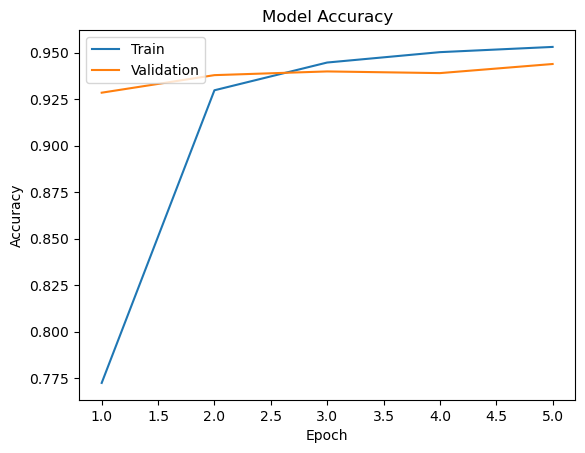

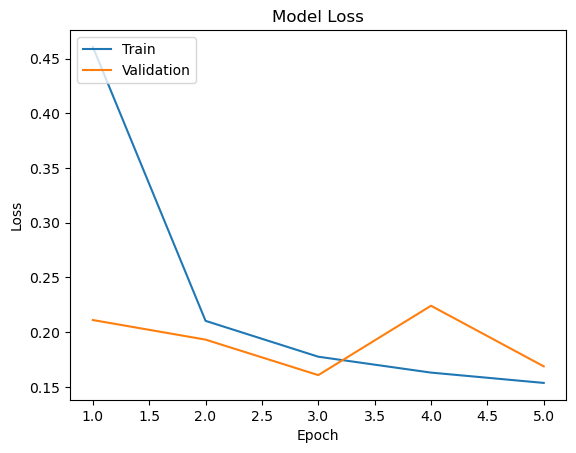

In [27]:
plotLearningCurve(history,5)

## VGG16 Model

In [48]:
train_gen = datagen.flow_from_directory(
    "cell_images\cell_images",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset='training'
)

Found 22048 images belonging to 2 classes.


In [49]:
val_gen = datagen.flow_from_directory(
    "cell_images\cell_images",
    target_size=(224, 224),
    batch_size=16,
    class_mode="binary",
    subset='validation'
)

Found 5510 images belonging to 2 classes.


In [50]:
from tensorflow.keras.applications import VGG16

In [51]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [52]:
from tensorflow.keras import layers, models, Input
import tensorflow as tf

In [53]:
inputs = Input(shape=(224,224,3))
x = base_model(inputs, training=False)     # hazır modelden geçir
x = layers.GlobalAveragePooling2D()(x)     # 2D feature map → 1D vektör
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

In [54]:
model = models.Model(inputs, outputs)

In [55]:
base_model.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_tl = model.fit(
    train_gen,                
    epochs=5,
    validation_data=val_gen
)

Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 1202s 2s/step - accuracy: 0.6635 - loss: 0.6189 - val_accuracy: 0.7998 - val_loss: 0.5241
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 1184s 2s/step - accuracy: 0.8116 - loss: 0.4720 - val_accuracy: 0.8376 - val_loss: 0.4300
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 1183s 2s/step - accuracy: 0.8456 - loss: 0.3980 - val_accuracy: 0.8639 - val_loss: 0.3731
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 1252s 2s/step - accuracy: 0.8687 - loss: 0.3479 - val_accuracy: 0.8759 - val_loss: 0.3335
Epoch 5/5
322/689 ━━━━━━━━━━━━━━━━━━━━ 8:22 1s/step - accuracy: 0.8801 - loss: 0.3249 

In [ ]:
print("melih")